In [287]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [288]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [289]:
print("Shape of the dataset is: ",df.shape)

Shape of the dataset is:  (10000, 14)


In [290]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [291]:
print('Total duplicate values: ',df.duplicated().sum())

Total duplicate values:  0


In [292]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [293]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [294]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [295]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)
print(df.columns)

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')


In [296]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype='int64')
print(df.head())

   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0               1        101348.88       1                  0   
1               1        112542.58       0                  0   
2               0        113931.57       1                  0   
3               0         93826.63       0                  0   
4               1         79084.10       0                  0   

   Geography_Spain  Gender_Male  
0                0            0  
1                1            0  
2                0            0  
3                0            0  
4                1            

In [297]:
y = df['Exited'].values
X = df.drop(columns=['Exited'])
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [298]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [299]:
print(X_train.shape)
print(y_train.shape)

(8000, 11)
(8000,)


In [300]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [301]:
model = Sequential()
model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [302]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [303]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [304]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [305]:
history = model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2,callbacks=[early_stopping])

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7639 - loss: 0.5613 - val_accuracy: 0.7975 - val_loss: 0.4866
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7998 - loss: 0.4585 - val_accuracy: 0.8069 - val_loss: 0.4451
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8159 - loss: 0.4333 - val_accuracy: 0.8144 - val_loss: 0.4300
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8211 - loss: 0.4226 - val_accuracy: 0.8144 - val_loss: 0.4220
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8267 - loss: 0.4151 - val_accuracy: 0.8181 - val_loss: 0.4176
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8288 - loss: 0.4094 - val_accuracy: 0.8156 - val_loss: 0.4115
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8288 - loss: 0.4027 - val_accuracy: 0.8175 - val_loss: 0.4051
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8336 - loss: 0.3954 - val_accu

In [306]:
model.layers[0].get_weights()

[array([[ 1.49034798e-01, -2.66905695e-01,  1.45101426e-02,
          3.17021050e-02, -2.84344673e-01,  4.37069505e-01,
         -2.88561195e-01, -3.28812413e-02,  2.05240995e-02,
          9.09904912e-02,  5.60400486e-01],
        [-7.74148703e-01, -4.99070585e-01, -1.35040641e-01,
         -4.57954884e-01, -1.90494567e-01,  3.06405693e-01,
         -5.05867362e-01, -1.02617383e-01, -7.16244698e-01,
         -1.64849594e-01,  9.11166310e-01],
        [-3.38355839e-01,  1.51144350e-02, -2.60542668e-02,
          1.68550655e-01, -2.75086373e-01, -2.64512926e-01,
          3.72208744e-01, -1.78359106e-01, -7.57495016e-02,
         -7.22122043e-02, -4.14004475e-01],
        [ 6.47481233e-02,  9.01200116e-01,  1.53262064e-01,
         -7.37708747e-01,  1.59400076e-01, -1.80731878e-01,
         -3.89510334e-01,  4.49211657e-01, -1.36883363e-01,
         -5.81480145e-01,  6.41578659e-02],
        [-7.67382234e-02, -4.40841317e-01,  9.09949839e-01,
          3.86322550e-02, -8.67705405e-01, -

In [307]:
model.layers[1].get_weights()

[array([[-1.0769736 , -0.4678176 ,  0.22019473,  0.7395222 , -0.01157916,
         -0.9608292 ,  0.39550313,  0.08529343,  0.43888846,  0.05221968,
          0.4403889 ],
        [-0.31967136, -0.01498181,  0.15581137, -0.07225726,  0.56763715,
         -0.1045839 , -0.08141122, -0.6396505 ,  0.5423684 , -0.28977615,
          0.20326023],
        [ 0.4931755 , -0.55466264,  0.220137  ,  0.2466787 , -0.25896013,
          0.32950845,  0.10290716, -0.6123901 , -0.03073333,  0.49699596,
          0.6044424 ],
        [ 0.05219516,  0.23550503,  0.70274633, -0.10999791, -0.3283501 ,
         -0.42984012,  0.52867323,  0.0153801 ,  0.05413277,  0.15737422,
          0.29353285],
        [ 0.00237202, -0.06361584, -0.29782832, -0.59359825,  0.13645186,
          0.4908374 ,  0.13802654, -0.641227  , -0.38482425,  0.30919135,
          0.26451126],
        [ 0.24364598,  0.23909712, -0.17944793,  0.44996214,  0.49520385,
          0.2829495 ,  0.374075  , -0.16061473,  0.05389427, -0.3616487

In [308]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [309]:
y_pred = np.where(y_log>0.5,1,0)
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [310]:
acc = accuracy_score(y_test,y_pred)
print(acc)

0.8595


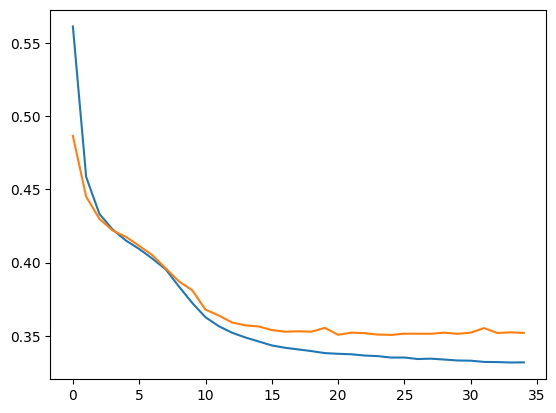

In [311]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

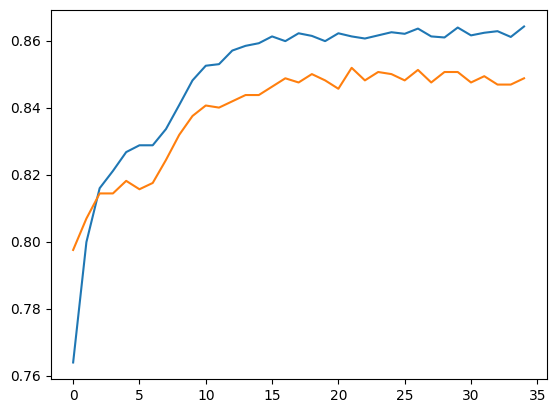

In [312]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

In [313]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

report = classification_report(y_test, y_pred)
print('\nClassification Report:')
print(report)

Confusion Matrix:
[[1529   56]
 [ 225  190]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1585
           1       0.77      0.46      0.57       415

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000

